In [3]:
def change_names(count_table_enhancer):
    #count_table_enhancer = count_table_enhancer.drop(["seq_ID",	"full_oligo_seq",	"enhancer_ID",	"barcode_ID"	,"contributor"],axis=1)
    column_names = []
    for i in count_table_enhancer.columns.str.split("-"):
    
        if i[0] == "26" or i[0]=="106" or i[0]=="109":
            i[0] = ""
        if i[2] == "26" or i[2]=="106" or i[2] =="109":
            i[2] = ""
        if i[-1] == "26" or i[-1]=="106" or i[-1]=="109":
            i[-1] = ""       
        if i[2][0:2]=="AP":
            i[2]="Mouse" + i[2]
        column_names.append(i[-1]+"_"+i[2]+"_"+i[0][:-1]+"_"+i[0][-1])

    for i in range(len(column_names)):
        column_names[i] = column_names[i].strip("_")

    count_table_enhancer.columns = column_names
    count_table_enhancer=count_table_enhancer.sort_index(axis=1)

    RNA_columns =[]
    DNA_columns = []

    for i in count_table_enhancer.columns:
        if i.split("-")[0][-1] == "R":
            RNA_columns.append(i)

        else:
            DNA_columns.append(i)
    return count_table_enhancer,RNA_columns, DNA_columns

In [3]:
import pandas as pd

def match_and_save_cell_data(dna_rna_file_path, enhancer_id_file_path, output_directory, cell_type, rename_dict=None):
    # Read DNA/RNA data
    count_table_barcode = pd.read_csv(dna_rna_file_path, index_col=0)
    
    # Rename columns if a rename dictionary is provided
    if rename_dict is not None:
        count_table_barcode = count_table_barcode.rename(rename_dict, axis=1)

    # Process data (assuming change_names is a defined function)
    matched_barcodes, RNA_columns, DNA_columns = change_names(count_table_barcode)
    DNA = matched_barcodes[DNA_columns]
    RNA = matched_barcodes[RNA_columns]

    # Match DNA data
    DNA_matched = pd.DataFrame()
    for i in RNA.columns:
        DNA_matched[i] = DNA[i[:-1] + "D"]

    # Prepare RNA data
    RNA_matched = RNA

    # Read enhancer IDs
    enhancer_id = pd.read_csv(enhancer_id_file_path, index_col="ID")["enhancer_id"]
    enhancer_id.columns = ["enhancer_id"]

    # Combine data
    RNA_matched = pd.concat([RNA_matched, enhancer_id], axis=1)
    DNA_matched = pd.concat([DNA_matched, enhancer_id], axis=1)

    # Save to CSV
    RNA_matched.to_csv(f"{output_directory}/{cell_type}_RNA_matched_barcodes.csv")
    DNA_matched.to_csv(f"{output_directory}/{cell_type}_DNA_matched_barcodes.csv")

# Example usage:
# rename_dict = {'ZC76RCol-MPRA3-HEK293T-26-Naive': 'ZC76R-MPRA3-HEK293T-26-Naive'}
# match_and_save_cell_data('/path/to/DNA_RNA.csv', '/path/to/df_MPRA3_20231110_R1R2.csv', './read_counts_R1R2', 'HEK293T', rename_dict)

#HEK293T
rename_dict = {'ZC76RCol-MPRA3-HEK293T-26-Naive': 'ZC76R-MPRA3-HEK293T-26-Naive'}
match_and_save_cell_data('read_counts_R1R2/HEK293T_DNA_RNA.csv', 'read_counts_R1R2/df_MPRA3_20231110_R1R2.csv', './read_counts_R1R2', 'HEK293T', rename_dict)


In [34]:
import pandas as pd
df_HEK293T = pd.read_csv('/media/zihengc/T7/ad_mpra_chen/outputs/read_counts_R1R2/HEK293T_DNA_matched_barcodes.csv',index_col=0).drop('enhancer_id',axis=1)
df_HEK293T.columns = df_HEK293T.columns+"DNA"
df_HEK293T.corr('pearson')

,Naive_HEK293T_ZC65_RDNA,Naive_HEK293T_ZC66_RDNA,Naive_HEK293T_ZC71_RDNA,Naive_HEK293T_ZC76_RDNA,Naive_HEK293T_ZC81_RDNA
Naive_HEK293T_ZC65_RDNA,1.000000,0.987360,0.993439,0.993367,0.991786
Naive_HEK293T_ZC66_RDNA,0.987360,1.000000,0.970651,0.977193,0.967684
Naive_HEK293T_ZC71_RDNA,0.993439,0.970651,1.000000,0.984192,0.985787
Naive_HEK293T_ZC76_RDNA,0.993367,0.977193,0.984192,1.000000,0.978816
Naive_HEK293T_ZC81_RDNA,0.991786,0.967684,0.985787,0.978816,1.000000


In [19]:
df_HEK293T.sum()

Naive_HEK293T_ZC65_RDNA    3199242.0
Naive_HEK293T_ZC66_RDNA    2214678.0
Naive_HEK293T_ZC71_RDNA    4419941.0
Naive_HEK293T_ZC76_RDNA    5036157.0
Naive_HEK293T_ZC81_RDNA    5027949.0
dtype: float64

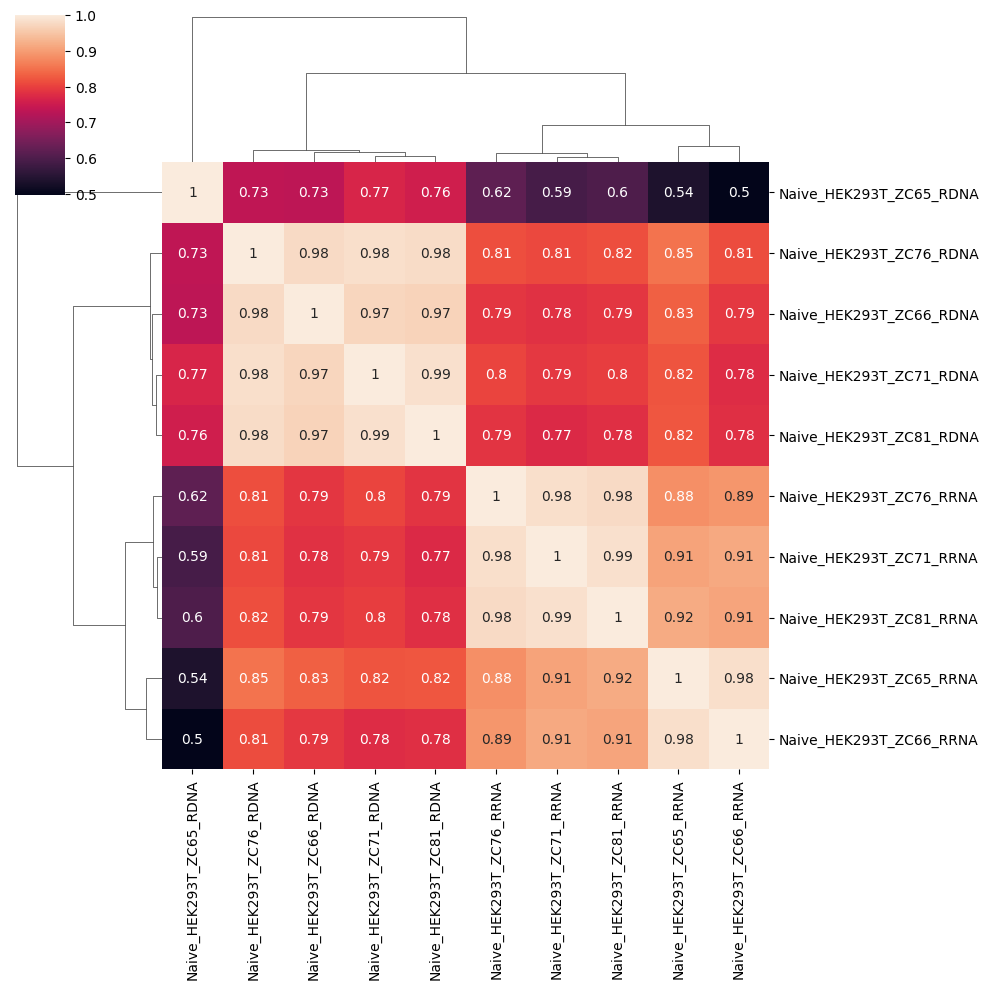

In [20]:
import seaborn as sns
df_HEK293T2 = pd.read_csv('/media/zihengc/T7/ad_mpra_chen/outputs/read_counts_R1R2/HEK293T_RNA_matched_barcodes.csv',index_col=0).drop('enhancer_id',axis=1)
df_HEK293T2.columns = df_HEK293T2.columns+"RNA"
sns.clustermap(pd.merge(df_HEK293T,df_HEK293T2,left_index=True,right_index=True).corr('pearson'),annot=True)

In [23]:
######################Replace ZC66's DNA counts with the averaged DNA count############################
import pandas as pd
df_HEK293T = pd.read_csv("read_counts_R1R2/HEK293T_DNA_matched_barcodes.csv",index_col=0)
selected_columns = ['Naive_HEK293T_ZC66_R', 'Naive_HEK293T_ZC71_R',
       'Naive_HEK293T_ZC76_R', 'Naive_HEK293T_ZC81_R']
ZC65 = round((df_HEK293T[selected_columns]/df_HEK293T[selected_columns].sum()).mean(axis=1)*5000000)
df_HEK293T['Naive_HEK293T_ZC65_R'] = ZC65
df_HEK293T.to_csv("read_counts_R1R2/HEK293T_DNA_matched_barcodes_new.csv")
df_HEK293T.drop('enhancer_id',axis=1).corr('spearman')

,Naive_HEK293T_ZC65_R,Naive_HEK293T_ZC66_R,Naive_HEK293T_ZC71_R,Naive_HEK293T_ZC76_R,Naive_HEK293T_ZC81_R
Naive_HEK293T_ZC65_R,1.000000,0.981330,0.990575,0.991416,0.991471
Naive_HEK293T_ZC66_R,0.981330,1.000000,0.959419,0.960498,0.961094
Naive_HEK293T_ZC71_R,0.990575,0.959419,1.000000,0.979223,0.978880
Naive_HEK293T_ZC76_R,0.991416,0.960498,0.979223,1.000000,0.981128
Naive_HEK293T_ZC81_R,0.991471,0.961094,0.978880,0.981128,1.000000


In [3]:
#THP1, needs matching manually
dna_rna_file_path = 'read_counts_R1R2/THP1_DNA_RNA.csv'
enhancer_id_file_path = 'read_counts_R1R2/df_MPRA3_20231110_R1R2.csv'
output_directory = './read_counts_R1R2'
cell_type = 'THP1'

# Read DNA/RNA data
count_table_barcode = pd.read_csv(dna_rna_file_path, index_col=0)

# Rename columns if a rename dictionary is provided
if rename_dict is not None:
    count_table_barcode = count_table_barcode.rename(rename_dict, axis=1)

# Process data (assuming change_names is a defined function)
matched_barcodes, RNA_columns, DNA_columns = change_names(count_table_barcode)
DNA = matched_barcodes[DNA_columns]
RNA = matched_barcodes[RNA_columns]

# Match DNA data
DNA_RNA_lookup = pd.read_csv( 'indexing/THP1_RNA_DNA_MatchTable.csv')
DNA_matched = DNA[DNA_RNA_lookup["DNA"]]
DNA_matched.columns = DNA_RNA_lookup["RNA"]
# Prepare RNA data
RNA_matched = RNA[DNA_RNA_lookup["RNA"]]

# Read enhancer IDs
enhancer_id = pd.read_csv(enhancer_id_file_path, index_col="ID")["enhancer_id"]
enhancer_id.columns = ["enhancer_id"]

# Combine data
RNA_matched = pd.concat([RNA_matched, enhancer_id], axis=1)
DNA_matched = pd.concat([DNA_matched, enhancer_id], axis=1)

# Save to CSV
RNA_matched.to_csv(f"{output_directory}/{cell_type}_RNA_matched_barcodes.csv")
DNA_matched.to_csv(f"{output_directory}/{cell_type}_DNA_matched_barcodes.csv")


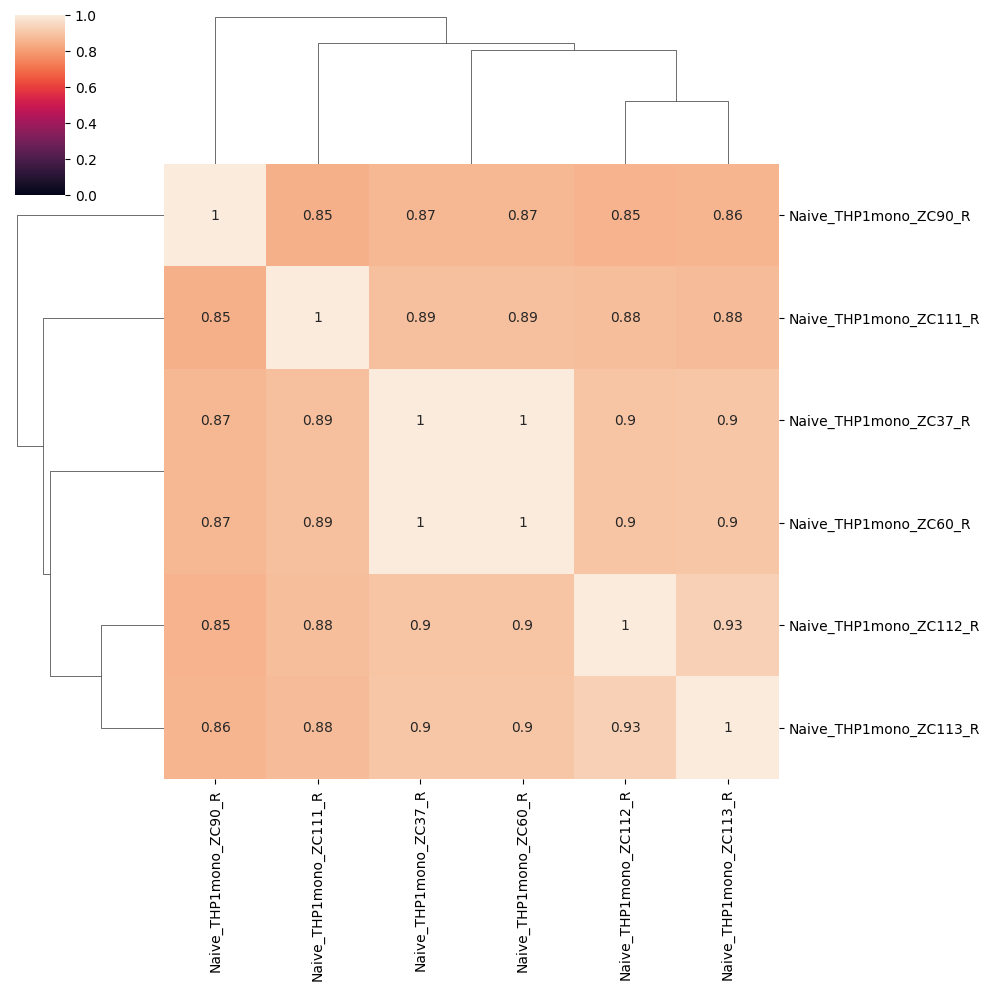

In [23]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("read_counts_R1R2/THP1_DNA_matched_barcodes.csv",index_col=0).drop("enhancer_id",axis=1)
sns.clustermap(df[['Naive_THP1mono_ZC111_R', 'Naive_THP1mono_ZC112_R',
       'Naive_THP1mono_ZC113_R', 'Naive_THP1mono_ZC37_R',
       'Naive_THP1mono_ZC60_R', 'Naive_THP1mono_ZC90_R']].corr('spearman'),vmin=0,annot=True)

In [4]:
#HMC3, needs matching manually
dna_rna_file_path = 'read_counts_R1R2/HMC3_DNA_RNA.csv'
enhancer_id_file_path = 'read_counts_R1R2/df_MPRA3_20231110_R1R2.csv'
output_directory = './read_counts_R1R2'
cell_type = 'HMC3'

# Read DNA/RNA data
count_table_barcode = pd.read_csv(dna_rna_file_path, index_col=0)
rename_dict = {
    'ZC22-24D-MPRA3-HMC3-26-Stim':'ZC22D-MPRA3-HMC3-26-Naive',
    'ZC3-5D-MPRA3-HMC3-26-Stim':'ZC3D-MPRA3-HMC3-26-Naive',
    'ZC72RAco-MPRA3-HMC3-26-Naive':'ZC72R-MPRA3-HMC3Aco-26-Naive', 
    'ZC72RCol-MPRA3-HMC3-26-Naive':'ZC72R-MPRA3-HMC3Col-26-Naive',
    'ZC73RAco-MPRA3-HMC3-26-IFNG':'ZC73R-MPRA3-HMC3Aco-26-IFNG', 
    'ZC73RCol-MPRA3-HMC3-26-IFNG':'ZC73R-MPRA3-HMC3Col-26-IFNG',
    'ZC74RAco-MPRA3-HMC3-26-IFNB':'ZC74R-MPRA3-HMC3Aco-26-IFNB', 
    'ZC74RCol-MPRA3-HMC3-26-IFNB':'ZC74R-MPRA3-HMC3Col-26-IFNB',
    'ZC75RAco-MPRA3-HMC3-26-LPSIFNG':'ZC75R-MPRA3-HMC3Aco-26-LPSIFNG', 
    'ZC75RCol-MPRA3-HMC3-26-LPSIFNG':'ZC75R-MPRA3-HMC3Col-26-LPSIFNG',
}

# Rename columns if a rename dictionary is provided
if rename_dict is not None:
    count_table_barcode = count_table_barcode.rename(rename_dict, axis=1)

# Process data (assuming change_names is a defined function)
matched_barcodes, RNA_columns, DNA_columns = change_names(count_table_barcode)
DNA = matched_barcodes[DNA_columns]
RNA = matched_barcodes[RNA_columns]

# Match DNA data
DNA_RNA_lookup = pd.read_csv( 'indexing/HMC3_RNA_DNA_MatchTable.csv')
DNA_matched = DNA[DNA_RNA_lookup["DNA"]]
DNA_matched.columns = DNA_RNA_lookup["RNA"]
# Prepare RNA data
RNA_matched = RNA[DNA_RNA_lookup["RNA"]]

# Read enhancer IDs
enhancer_id = pd.read_csv(enhancer_id_file_path, index_col="ID")["enhancer_id"]
enhancer_id.columns = ["enhancer_id"]

# Combine data
RNA_matched = pd.concat([RNA_matched, enhancer_id], axis=1)
DNA_matched = pd.concat([DNA_matched, enhancer_id], axis=1)

# Save to CSV
RNA_matched.to_csv(f"{output_directory}/{cell_type}_RNA_matched_barcodes.csv")
DNA_matched.to_csv(f"{output_directory}/{cell_type}_DNA_matched_barcodes.csv")

In [4]:
#HMC3, needs matching manually
import pandas as pd
dna_rna_file_path = 'read_counts_R2only/HMC3_DNA_RNA.csv'
enhancer_id_file_path = 'read_counts_R2only/df_MPRA3_20231108_R2.csv'
output_directory = './read_counts_R2only'
cell_type = 'HMC3'

# Read DNA/RNA data
count_table_barcode = pd.read_csv(dna_rna_file_path, index_col=0)
rename_dict = {
    'ZC22-24D-MPRA3-HMC3-26-Stim':'ZC22D-MPRA3-HMC3-26-Naive',
    'ZC3-5D-MPRA3-HMC3-26-Stim':'ZC3D-MPRA3-HMC3-26-Naive',
    'ZC72RAco-MPRA3-HMC3-26-Naive':'ZC72R-MPRA3-HMC3Aco-26-Naive', 
    'ZC72RCol-MPRA3-HMC3-26-Naive':'ZC72R-MPRA3-HMC3Col-26-Naive',
    'ZC73RAco-MPRA3-HMC3-26-IFNG':'ZC73R-MPRA3-HMC3Aco-26-IFNG', 
    'ZC73RCol-MPRA3-HMC3-26-IFNG':'ZC73R-MPRA3-HMC3Col-26-IFNG',
    'ZC74RAco-MPRA3-HMC3-26-IFNB':'ZC74R-MPRA3-HMC3Aco-26-IFNB', 
    'ZC74RCol-MPRA3-HMC3-26-IFNB':'ZC74R-MPRA3-HMC3Col-26-IFNB',
    'ZC75RAco-MPRA3-HMC3-26-LPSIFNG':'ZC75R-MPRA3-HMC3Aco-26-LPSIFNG', 
    'ZC75RCol-MPRA3-HMC3-26-LPSIFNG':'ZC75R-MPRA3-HMC3Col-26-LPSIFNG',
}

# Rename columns if a rename dictionary is provided
if rename_dict is not None:
    count_table_barcode = count_table_barcode.rename(rename_dict, axis=1)

# Process data (assuming change_names is a defined function)
matched_barcodes, RNA_columns, DNA_columns = change_names(count_table_barcode)
DNA = matched_barcodes[DNA_columns]
RNA = matched_barcodes[RNA_columns]

# Match DNA data
DNA_RNA_lookup = pd.read_csv( 'indexing/HMC3_RNA_DNA_MatchTable.csv')
DNA_matched = DNA[DNA_RNA_lookup["DNA"]]
DNA_matched.columns = DNA_RNA_lookup["RNA"]
# Prepare RNA data
RNA_matched = RNA[DNA_RNA_lookup["RNA"]]

# Read enhancer IDs
enhancer_id = pd.read_csv(enhancer_id_file_path, index_col="ID")["enhancer_id"]
enhancer_id.columns = ["enhancer_id"]

# Combine data
RNA_matched = pd.concat([RNA_matched, enhancer_id], axis=1)
DNA_matched = pd.concat([DNA_matched, enhancer_id], axis=1)

# Save to CSV
RNA_matched.to_csv(f"{output_directory}/{cell_type}_RNA_matched_barcodes.csv")
DNA_matched.to_csv(f"{output_directory}/{cell_type}_DNA_matched_barcodes.csv")

/tmp/ipykernel_34459/313021.py:40: DtypeWarning: Columns (164) have mixed types. Specify dtype option on import or set low_memory=False.
  enhancer_id = pd.read_csv(enhancer_id_file_path, index_col="ID")["enhancer_id"]


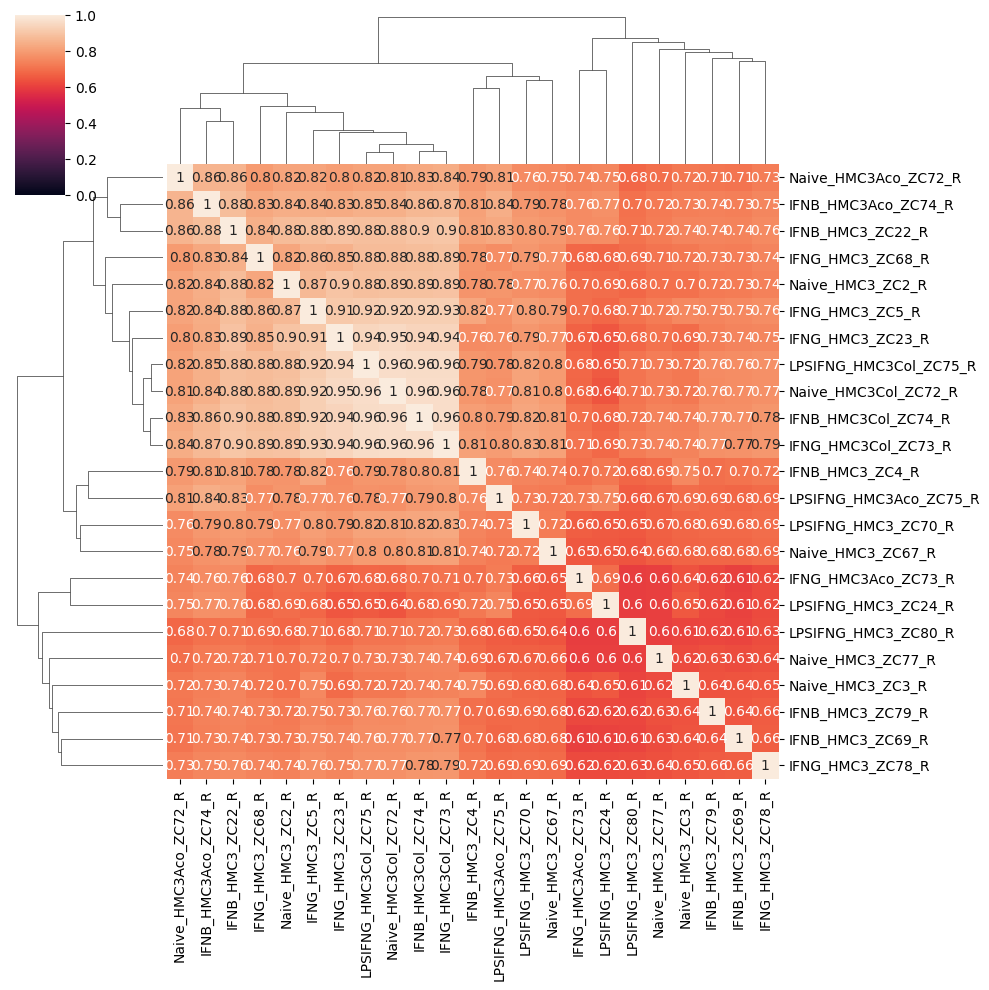

In [17]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("read_counts_R1R2/HMC3_RNA_matched_barcodes.csv",index_col=0).drop("enhancer_id",axis=1)
sns.clustermap(df.corr('spearman'),vmin=0,annot=True)